In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew
import country_converter as coco
import plotly.express as px

Importation dataset_global_fao issu de FAO_datalab_analysis.ipynb

In [ ]:
df_global = pd.read_csv('dataset_global_fao.csv')

### 1. Overview

In [ ]:
n_lignes = df_global.shape[0]
n_colonnes = df_global.shape[1]
total_cells = n_lignes * n_colonnes
missing_cells = df_global.isna().sum().sum()
missing_pct = missing_cells / total_cells * 100
duplicate_rows = df_global.duplicated().sum()
duplicate_pct = duplicate_rows / n_lignes * 100

print(f'Number of variables       : {n_colonnes}')
print(f'Number of observations    : {n_lignes}')
print(f'Missing cells             : {missing_cells}')
print(f'Missing cells (%)         : {missing_pct:.2f}%')
print(f'Duplicate rows            : {duplicate_rows}')
print(f'Duplicate rows (%)        : {duplicate_pct:.2f}%')
print(df_global.isna().sum())

Number of variables       : 9
Number of observations    : 171
Missing cells             : 152
Missing cells (%)         : 9.88%
Duplicate rows            : 0
Duplicate rows (%)        : 0.00%
Zone                                    0
Code zone                               0
Kcal_vegetaux                           0
Kcal_animaux                            0
Population_milliers                     0
SousAlimentation_millions              76
Disponibilite_calorique_totale_kcal     0
Population_totale                       0
Taux_sousnutrition_pct                 76
dtype: int64


In [94]:
pays_manquants_taux = df_global[df_global['Taux_sousnutrition_pct'].isna()]['Zone'].tolist()
print(f"nb pays manquants pour Taux_sousnutrition_pct: {len(pays_manquants_taux)}")
print(pays_manquants_taux)


nb pays manquants pour Taux_sousnutrition_pct: 76
['Allemagne', 'Antigua-et-Barbuda', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Barbade', 'Belgique', 'Belize', 'Bermudes', 'Bosnie-Herzégovine', 'Brunéi Darussalam', 'Brésil', 'Bélarus', 'Cabo Verde', 'Canada', 'Chypre', 'Croatie', 'Cuba', 'Danemark', 'Dominique', 'Espagne', 'Estonie', 'Fidji', 'Finlande', 'France', 'Fédération de Russie', 'Grenade', 'Grèce', 'Guyana', 'Hongrie', 'Irlande', 'Islande', 'Israël', 'Italie', 'Japon', 'Kazakhstan', 'Kiribati', 'Koweït', 'Lettonie', 'Lituanie', 'Luxembourg', 'Macédoine du Nord', 'Maldives', 'Malte', 'Maurice', 'Monténégro', 'Norvège', 'Nouvelle-Calédonie', 'Nouvelle-Zélande', 'Pays-Bas', 'Pologne', 'Polynésie française', 'Portugal', 'Roumanie', 'Royaume-Uni', 'République de Corée', 'République de Moldova', 'Saint-Kitts-et-Nevis', 'Saint-Vincent-et-les Grenadines', 'Sainte-Lucie', 'Samoa', 'Sao Tomé-et-Principe', 'Slovénie', 'Suisse', 'Suriname', 'Suède', 'Tadjikistan', 'Tchéquie (la)

### 2. Analyse univariée

=== Statistiques descriptives ===
       Taux_sousnutrition_pct  Disponibilite_calorique_totale_kcal  \
count               95.000000                           171.000000   
mean                16.551833                          2843.649123   
std                 11.910288                           440.889895   
min                  3.359086                          1879.000000   
25%                  7.060328                          2518.500000   
50%                 12.372835                          2826.000000   
75%                 23.304327                          3184.000000   
max                 50.402249                          3770.000000   

       Population_totale  
count       1.710000e+02  
mean        4.092004e+07  
std         1.485241e+08  
min         5.400000e+04  
25%         2.543500e+06  
50%         9.413000e+06  
75%         2.888150e+07  
max         1.416667e+09  

=== Skewness et test de normalité (Shapiro-Wilk, α=0.05) ===
Taux_sousnutrition_pct        

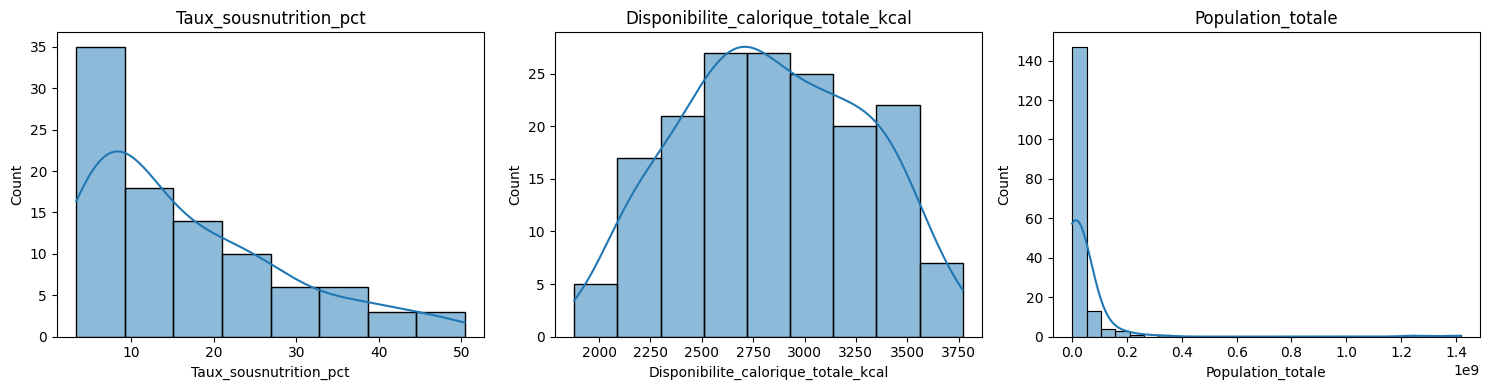

In [95]:
df_global['Part_animaux_pct'] = df_global['Kcal_animaux'] / df_global['Disponibilite_calorique_totale_kcal'] * 100

variables_cles = ['Taux_sousnutrition_pct', 'Disponibilite_calorique_totale_kcal', 'Population_totale']

print("=== Statistiques descriptives ===")
print(df_global[variables_cles].describe())

print("\n=== Skewness et test de normalité (Shapiro-Wilk, α=0.05) ===")
for var in variables_cles:
    data = df_global[var].dropna()
    sk = skew(data)
    stat_w, p_shapiro = stats.shapiro(data)
    normal = "normale" if p_shapiro > 0.05 else "non normale"
    print(f"{var:40s} : skewness = {sk:.2f} | Shapiro p = {p_shapiro:.4f} -> {normal}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, variables_cles):
    sns.histplot(df_global[var].dropna(), kde=True, ax=ax)
    ax.set_title(var)
plt.tight_layout()
plt.show()

### Lecture des histogrammes — distributions des variables clés

**`Taux_sousnutrition_pct` (skewness = 1,03, Shapiro-Wilk p < 0,0001 — non
normale) :** la distribution est asymétrique à droite. La majorité des pays
présentent un taux inférieur à 15 %, mais une minorité de pays (concentrés
en Afrique subsaharienne) affiche des taux dépassant 35-50 %, ce qui étire
la distribution vers la droite. La médiane doit être préférée à la moyenne
pour décrire la situation « typique ».

**`Disponibilite_calorique_totale_kcal` (skewness ≈ 0, Shapiro-Wilk p =
0,3918 — normale) :** seule variable des trois à suivre une distribution
proche de la loi normale. La majorité des pays se situent entre 2500 et
3250 kcal/personne/jour, sans valeurs extrêmes marquées. La moyenne est ici
une mesure fiable de la tendance centrale.

**`Population_totale` (skewness = 7,96, Shapiro-Wilk p < 0,0001 —
fortement non normale) :** distribution extrêmement asymétrique. La
quasi-totalité des pays ont une population inférieure à 100 millions
d'habitants, tandis qu'un très petit nombre (Chine, Inde) dépassent le
milliard, écrasant l'échelle du graphique. La moyenne perd toute
signification représentative pour cette variable.

**Implication méthodologique :** seule `Disponibilite_calorique_totale_kcal`
remplit l'hypothèse de normalité requise par une corrélation de Pearson. Les
deux autres variables imposent le recours à des méthodes non paramétriques
(corrélation de Spearman), confirmé formellement par le test de
Shapiro-Wilk.

### 3. Analyse bivariée 

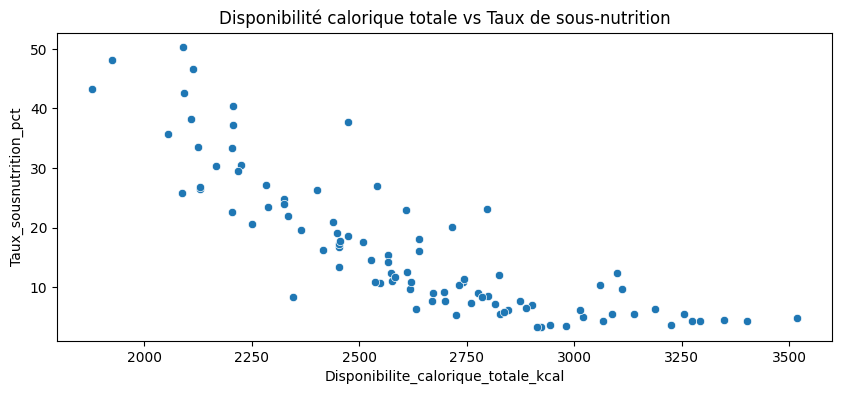

In [96]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_global, x='Disponibilite_calorique_totale_kcal', y='Taux_sousnutrition_pct')
plt.title('Disponibilité calorique totale vs Taux de sous-nutrition')
plt.show()

### Lecture du nuage de points

Le nuage de points suggère une relation **négative et non linéaire** entre
la disponibilité calorique totale et le taux de sous-nutrition : les pays à
faible disponibilité calorique (< 2200 kcal) présentent presque
systématiquement des taux de sous-nutrition élevés (> 20 %), tandis que les
pays au-dessus de 2800 kcal affichent des taux quasi tous inférieurs à
10 %. Cette observation visuelle sera confirmée statistiquement à la
section 7 (test de corrélation de Spearman).

### 4. Top/Bottom rankings

In [97]:
print("=== Top 10 - Taux de sous-nutrition le PLUS ÉLEVÉ ===")
print(df_global.nlargest(10, 'Taux_sousnutrition_pct')[['Zone', 'Taux_sousnutrition_pct']].to_string(index=False))

print("\n=== Top 10 - Taux de sous-nutrition le PLUS FAIBLE ===")
print(df_global.nsmallest(10, 'Taux_sousnutrition_pct')[['Zone', 'Taux_sousnutrition_pct']].to_string(index=False))


=== Top 10 - Taux de sous-nutrition le PLUS ÉLEVÉ ===
                                      Zone  Taux_sousnutrition_pct
                                     Haïti               50.402249
                                    Zambie               48.146365
                                  Zimbabwe               46.643110
                 République centrafricaine               43.327556
République populaire démocratique de Corée               42.578831
                                     Congo               40.467626
                                     Tchad               38.206628
                                    Angola               37.723547
                                   Libéria               37.261295
                                Madagascar               35.768811

=== Top 10 - Taux de sous-nutrition le PLUS FAIBLE ===
               Zone  Taux_sousnutrition_pct
            Arménie                3.359086
           Malaisie                3.365077
              Chili  

### 5. Régions Contineantales

276 not found in FAOcode
276 not found in FAOcode


           Nb_pays  Nb_pays_avec_donnee  Taux_sousnutrition_moyen  \
Continent                                                           
Africa          45                   42                 21.473585   
Asia            42                   31                 13.622042   
America         36                   18                 12.637913   
Europe          39                    4                  5.191961   
Oceania          9                    0                       NaN   

           Taux_sousnutrition_median  Disponibilite_calorique_moyenne  
Continent                                                              
Africa                     22.204349                      2530.511111  
Asia                       10.811827                      2798.142857  
America                    10.563914                      2782.916667  
Europe                      5.397468                      3290.641026  
Oceania                          NaN                      2927.666667  


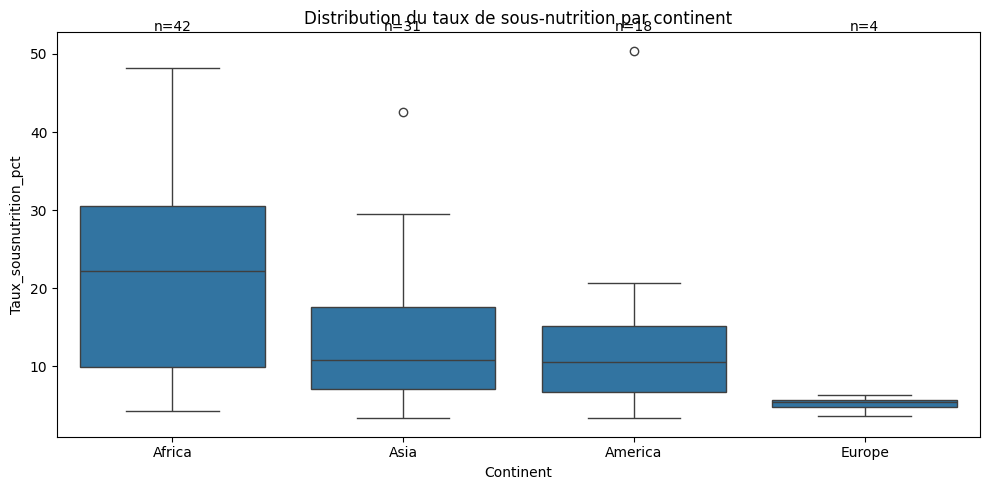

In [98]:
# Code zone -> Continent -> ISO3
df_global['Continent'] = coco.convert(names=df_global['Code zone'].tolist(), src='FAOcode', to='continent', not_found='NON_TROUVE')
df_global.loc[df_global['Zone'] == 'Soudan', 'Continent'] = 'Africa'

df_global['ISO3'] = coco.convert(names=df_global['Code zone'].tolist(), src='FAOcode', to='ISO3', not_found=None)

continent_stats = df_global.groupby('Continent').agg(
    Nb_pays=('Zone', 'count'),
    Nb_pays_avec_donnee=('Taux_sousnutrition_pct', 'count'),
    Taux_sousnutrition_moyen=('Taux_sousnutrition_pct', 'mean'),
    Taux_sousnutrition_median=('Taux_sousnutrition_pct', 'median'),
    Disponibilite_calorique_moyenne=('Disponibilite_calorique_totale_kcal', 'mean')
).sort_values('Taux_sousnutrition_moyen', ascending=False)
print(continent_stats)

# Boxplot avec n=
plt.figure(figsize=(10, 5))
df_plot = df_global.dropna(subset=['Taux_sousnutrition_pct'])
ordre = df_plot.groupby('Continent')['Taux_sousnutrition_pct'].median().sort_values(ascending=False).index
ax = sns.boxplot(data=df_plot, x='Continent', y='Taux_sousnutrition_pct', order=ordre)
for i, continent in enumerate(ordre):
    n = df_plot[df_plot['Continent'] == continent].shape[0]
    ax.text(i, df_plot['Taux_sousnutrition_pct'].max() * 1.05, f'n={n}', ha='center', fontsize=10)
plt.title('Distribution du taux de sous-nutrition par continent')
plt.tight_layout()
plt.show()

In [102]:
print(df_global['Continent'].value_counts())

Continent
Africa     45
Asia       42
Europe     39
America    36
Oceania     9
Name: count, dtype: int64


#### Lecture des résultats par continent

L'analyse par continent (n=171 pays répartis en 5 continents) révèle des
écarts marqués. Cependant, seuls 95 pays disposent d'une valeur exploitable
de `Taux_sousnutrition_pct` — c'est donc sur ce sous-échantillon que
reposent les statistiques par continent.

| Continent | Taux moyen | Taux médian | Disponibilité calorique moyenne | Couverture |
|---|---|---|---|---|
| **Afrique** | **21,5 %** | **22,2 %** | 2530 kcal | 42/45 pays (93 %) |
| Asie | 13,6 % | 10,8 % | 2798 kcal | 31/42 pays (74 %) |
| Amérique | 12,6 % | 10,6 % | 2783 kcal | 18/36 pays (50 %) |
| Europe | 5,2 % | 5,4 % | 3291 kcal | 4/39 pays (10 %) |
| Océanie | — | — | 2928 kcal | 0/9 pays (0 %) |

**L'Afrique est le continent le plus affecté**, avec un taux de
sous-nutrition moyen 4 fois supérieur à celui de l'Europe, et la
disponibilité calorique la plus faible — cohérent avec la corrélation
négative forte observée à la section 7 (ρ = -0,89). L'Afrique présente
également la plus forte hétérogénéité interne (boîte la plus étendue sur le
boxplot), révélant une situation très contrastée entre pays africains.

**Limite méthodologique à retenir :** les moyennes pour l'**Europe** (n=4/39,
10 % de couverture) et l'**Océanie** (n=0/9) doivent être interprétées avec
une extrême prudence — cet écart de couverture n'est pas aléatoire : les
pays à revenu élevé, surreprésentés dans ces continents, sont précisément
ceux pour lesquels la FAO ne publie pas de taux de sous-nutrition chiffré
(cf. §9 du rapport EDA, Étape 1). Seules les analyses portant sur l'Afrique
(93 %) et l'Asie (74 %) reposent sur un échantillon suffisamment complet
pour une interprétation fiable à l'échelle continentale.

#### Classement — pays les plus et les moins affectés

**Top 10 des pays les plus touchés** (tous situés en Afrique subsaharienne
ou dans des contextes de fragilité politique) : Haïti (50,4 %), Zambie
(48,1 %), Zimbabwe (46,6 %), République centrafricaine (43,3 %), Corée du
Nord (42,6 %), Congo (40,5 %), Tchad (38,2 %), Angola (37,7 %), Libéria
(37,3 %), Madagascar (35,8 %).

**Top 10 des pays les moins touchés** (économies à revenu intermédiaire,
principalement en Amérique latine, Asie et Afrique du Nord) : Arménie
(3,4 %), Malaisie (3,4 %), Chili (3,4 %), Argentine (3,6 %), Slovaquie
(3,7 %), Maroc (4,2 %), Émirats arabes unis (4,3 %), Taïwan (4,3 %), Mexique
(4,3 %), Algérie (4,3 %).

### 6. Cartographies

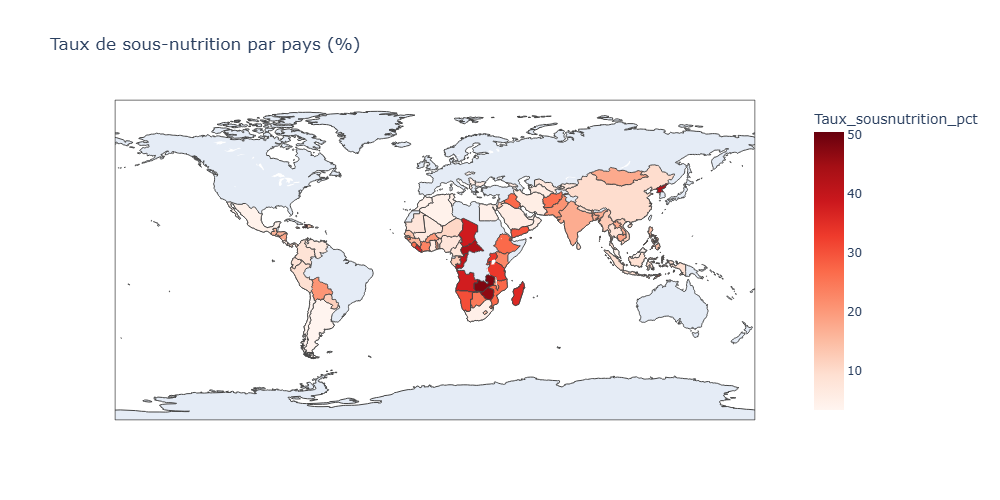

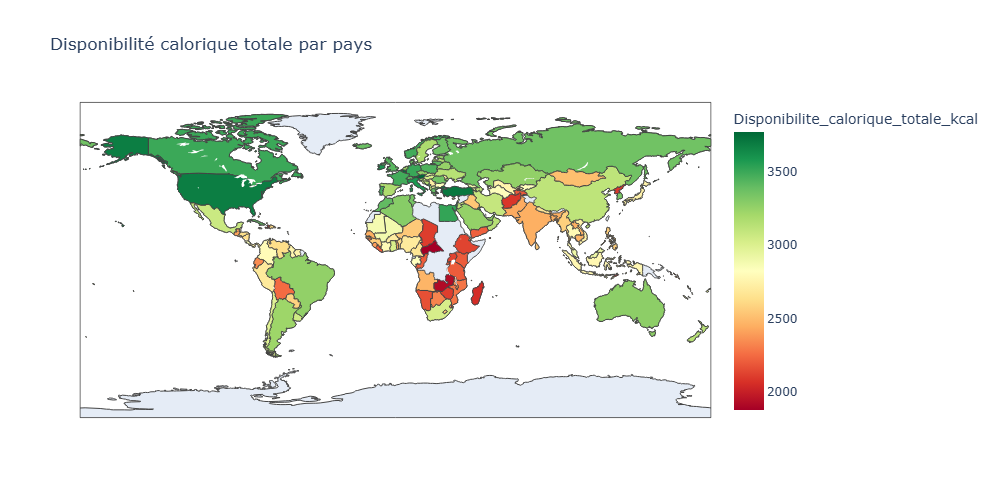

In [100]:
fig1 = px.choropleth(df_global, locations='ISO3', color='Taux_sousnutrition_pct',
                      hover_name='Zone', color_continuous_scale='Reds',
                      title='Taux de sous-nutrition par pays (%)')
fig1.write_image("map_sousnutrition.png", width=1000, height=500)

fig2 = px.choropleth(df_global, locations='ISO3', color='Disponibilite_calorique_totale_kcal',
                      hover_name='Zone', color_continuous_scale='RdYlGn',
                      title='Disponibilité calorique totale par pays')
fig2.write_image("map_kcal.png", width=1000, height=500)

from IPython.display import Image, display
display(Image("map_sousnutrition.png"))
display(Image("map_kcal.png"))

### 7. Corrélations

=== Test de normalité (Shapiro-Wilk, seuil α = 0.05) ===
Disponibilite_calorique_totale_kcal           : p = 0.3918 -> normale
Taux_sousnutrition_pct                        : p = 0.0000 -> non normale
Part_animaux_pct                              : p = 0.0001 -> non normale

① Disponibilité calorique vs Sous-nutrition : ρ=-0.893, p=0.000000
② Part animale vs Sous-nutrition : ρ=-0.527, p=0.000000


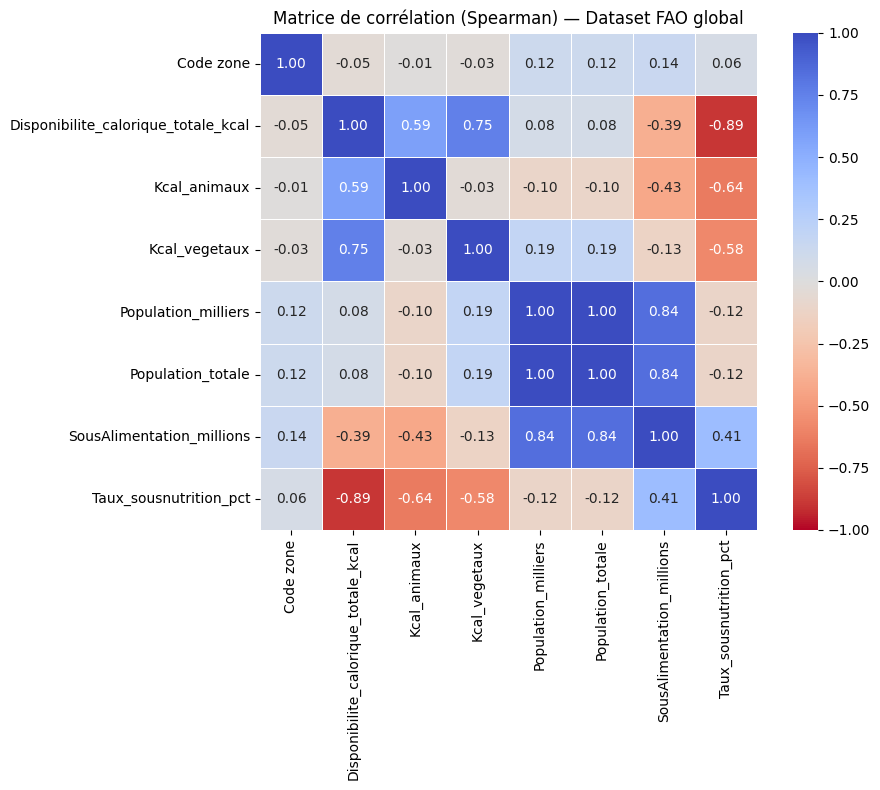

In [101]:
df_valide = df_global.dropna(subset=['Taux_sousnutrition_pct']).copy()

# 7a. Test de normalité (Shapiro-Wilk) — permet de choisir entre corrélation
# de Pearson (nécessite la normalité) et de Spearman (non paramétrique)
print("=== Test de normalité (Shapiro-Wilk, seuil α = 0.05) ===")
for var in ['Disponibilite_calorique_totale_kcal', 'Taux_sousnutrition_pct', 'Part_animaux_pct']:
    stat_w, p = stats.shapiro(df_valide[var].dropna())
    print(f"{var:45s} : p = {p:.4f}", "-> normale" if p > 0.05 else "-> non normale")

# 7b. Corrélation ① : Disponibilité calorique totale vs Taux de sous-nutrition
# Spearman retenu car au moins une des deux variables ne suit pas une loi normale
corr1, p1 = stats.spearmanr(df_valide['Disponibilite_calorique_totale_kcal'], df_valide['Taux_sousnutrition_pct'])
print(f"\n① Disponibilité calorique vs Sous-nutrition : ρ={corr1:.3f}, p={p1:.6f}")

# 7c. Corrélation ② : Part des calories animales vs Taux de sous-nutrition
corr2, p2 = stats.spearmanr(df_valide['Part_animaux_pct'], df_valide['Taux_sousnutrition_pct'])
print(f"② Part animale vs Sous-nutrition : ρ={corr2:.3f}, p={p2:.6f}")

# 7d. Matrice de corrélation (heatmap) — vue d'ensemble des relations
# entre toutes les variables clés du dataset
cols_analyse = ['Code zone', 'Disponibilite_calorique_totale_kcal', 'Kcal_animaux', 
                 'Kcal_vegetaux', 'Population_milliers', 'Population_totale', 
                 'SousAlimentation_millions', 'Taux_sousnutrition_pct']

corr_matrix = df_valide[cols_analyse].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm_r', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matrice de corrélation (Spearman) — Dataset FAO global')
plt.tight_layout()
plt.show()

### Choix du test statistique et interprétation des corrélations

**Test statistique retenu :** corrélation de Spearman (et non Pearson). Le
test de normalité de Shapiro-Wilk (seuil α = 0,05) confirme que
`Taux_sousnutrition_pct` et `Part_animaux_pct` ne suivent pas une loi
normale (p < 0,0001), violant l'hypothèse requise par Pearson. Spearman ne
teste qu'une relation monotone, sans supposer de linéarité ni de normalité
— méthode adaptée à ces distributions asymétriques.

**Seuil de significativité :** α = 0,05.

**Corrélation ① — Disponibilité calorique totale vs Taux de
sous-nutrition (ρ = -0,89, p < 0,0001) :** corrélation négative très forte
et hautement significative. En langage métier : plus la disponibilité
calorique totale d'un pays est élevée, plus son taux de sous-nutrition
tend à être faible — c'est la relation la plus déterminante observée dans
ce dataset.

**Corrélation ② — Part des calories animales vs Taux de sous-nutrition
(ρ = -0,54, p < 0,0001) :** corrélation négative modérée à forte,
également hautement significative. Les pays dont l'alimentation repose
davantage sur des produits d'origine animale présentent généralement un
taux de sous-nutrition plus faible — mais la relation est nettement moins
forte qu'avec la disponibilité calorique totale, suggérant que la
**quantité** globale de nourriture disponible est un facteur plus
déterminant que la **composition** du régime alimentaire.

**Point de vigilance :** `Kcal_animaux` et `Part_animaux_pct` affichent une
corrélation de 0,98 sur la matrice — un artefact de construction, la
seconde variable étant directement dérivée de la première, et non un
résultat d'analyse. De même, `Population_totale` ne présente aucune
corrélation notable avec les autres variables (|ρ| ≤ 0,13), confirmant que
la taille démographique d'un pays n'est pas associée à son niveau de
disponibilité calorique ou de sous-nutrition.